# In this lab we will do 
- split datasets into training, cross validation, and test sets
- evaluate regression and classification models
- add polynomial features to improve the performance of a linear regression model
  

In [1]:
import numpy as np
# for building linear regression models and preparing data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
# for building and training NN
import tensorflow as tf
# for ploting
import matplotlib.pyplot as plt

# Data

In [2]:
data =np.loadtxt(r"E:\SALEH\Data\data_w3_ex1.csv",delimiter=',')

In [3]:
X = data[:,0] # feature
y = data[:,1] # target

X = np.expand_dims(X,axis=1)
y = np.expand_dims(y,axis=1)

In [4]:
print(f"the shape of the inputs x is: {X.shape}")
print(f"the shape of the targets y is: {y.shape}")

the shape of the inputs x is: (50, 1)
the shape of the targets y is: (50, 1)


### Split the data into Training set,Cross validation and Test set

- `Training set 60%`: Used to train the model
- `Cross validation 20%`: Used to choose the model hyperparameters(e.g, degree)
- `test set 20%`: Used to deliver a fair estimate of chosen model's preformance (to see the final performance)

we choose the `d`(degree) using `CV`(cross validation),then we check the `test set`, with this we get a realistic estimate of how the model generalizes to unseen data  

---
`Scikit-learn` provides a train_test_split function to split your data into the parts mentioned above




In [5]:
from sklearn.model_selection import train_test_split

In [6]:
# 60% for Training set
X_train,x_,y_train,y_ = train_test_split(X,y,test_size=0.40,random_state=1)

In [7]:
# 20% for CV and Test set
X_cv,X_test,y_cv,y_test = train_test_split(x_,y_,test_size=0.50,random_state=1)

del x_,y_

In [8]:
print(f"the shape of the training set (input) is: {X_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {X_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {X_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (30, 1)
the shape of the training set (target) is: (30, 1)

the shape of the cross validation set (input) is: (10, 1)
the shape of the cross validation set (target) is: (10, 1)

the shape of the test set (input) is: (10, 1)
the shape of the test set (target) is: (10, 1)


# visualizing the `Training set`,`Cross validation` and `Test set`

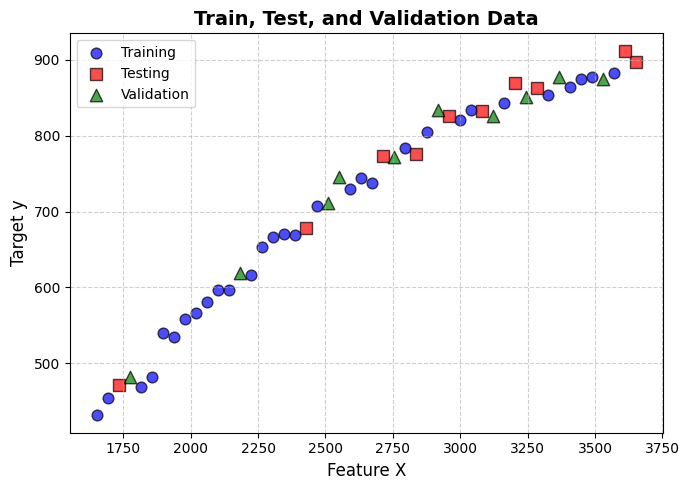

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Training data
plt.scatter(X_train, y_train, 
            color="blue", marker="o", s=60, alpha=0.7, 
            edgecolor="k", label="Training")

# Testing data
plt.scatter(X_test, y_test, 
            color="red", marker="s", s=70, alpha=0.7, 
            edgecolor="k", label="Testing")

# Cross-validation data
plt.scatter(X_cv, y_cv, 
            color="green", marker="^", s=80, alpha=0.7, 
            edgecolor="k", label="Validation")


plt.xlabel("Feature X", fontsize=12)
plt.ylabel("Target y", fontsize=12)
plt.title("Train, Test, and Validation Data", fontsize=14, fontweight="bold")


plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# $$Feature scaling$$

- In training set we use `fit_transform`
  - Learns from the data only `fit`
  - apply the scaler `transform`

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

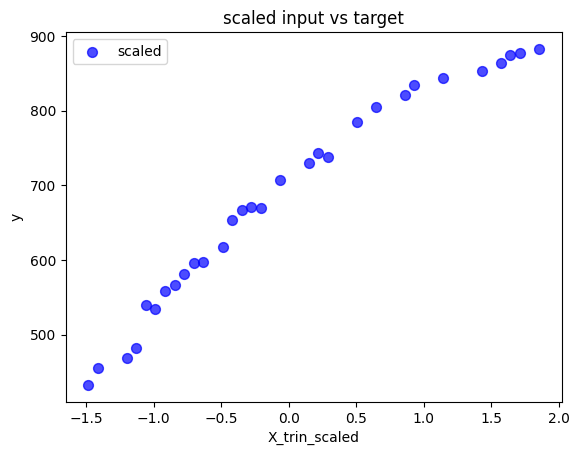

In [12]:
plt.scatter(X_train_scaled, y_train, color="blue", marker="o",s=50,alpha=0.7,label='scaled')
plt.legend()
plt.xlabel("X_train_scaled")
plt.ylabel("y")
plt.title("scaled input vs target")
plt.show()

# Training the model using `linear regressor` from scikit-learn

- For model training we use the `training set`

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
linear_model = LinearRegression()
#train the model
linear_model.fit(X_train_scaled,y_train)

LinearRegression()

# Model evaluation

to evaluate the performance , we measure the error of training and cross validation sets 


for `training error` :
$$J_{train}(\vec{w}, b) = \frac{1}{2m_{train}}\left[\sum_{i=1}^{m_{train}}(f_{\vec{w},b}(\vec{x}_{train}^{(i)}) - y_{train}^{(i)})^2\right]$$





In [15]:
from sklearn.metrics import mean_squared_error

In [16]:
# feed the scaled training set to get predictions 
y_hat = linear_model.predict(X_train_scaled)

print(f"training MSE (using sklearn function): {mean_squared_error(y_train, y_hat) / 2}")


training MSE (using sklearn function): 406.19374192533155


In [17]:
# loop 
total_squared_error = 0
for i in range(len(y_hat)):
    squared_error_i  = (y_hat[i] - y_train[i])**2
    total_squared_error += squared_error_i                                              

mse = total_squared_error / (2*len(y_hat))

print(f"training MSE (for-loop implementation): {mse.squeeze()}")

training MSE (for-loop implementation): 406.19374192533155


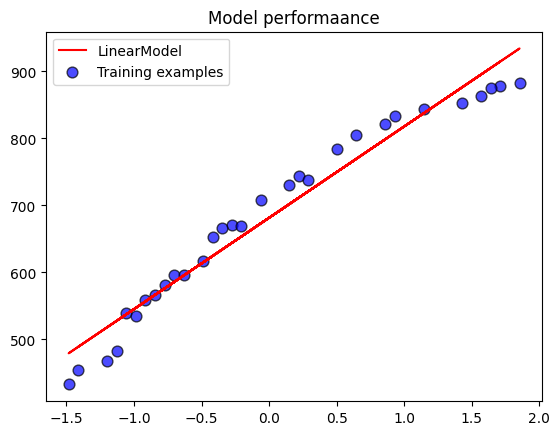

In [18]:
plt.plot(X_train_scaled,y_hat,c = "red",label='LinearModel')

# scatter plot
plt.scatter(X_train_scaled,y_train,marker='o',s=60,alpha=0.7,edgecolor='k',label='Training examples',color='blue')
plt.title("Model performaance")
plt.legend()
plt.show()



## Now we compute the the MSE using Cross validation set

$$J_{cv}(\vec{w}, b) = \frac{1}{2m_{cv}}\left[\sum_{i=1}^{m_{cv}}(f_{\vec{w},b}(\vec{x}_{cv}^{(i)}) - y_{cv}^{(i)})^2\right]$$


- Same as training set we scale it using `StandardScaler` But this time using `transform`
  - just apply the transformation (z-score)
  - it does not learn again
  - used in `CV` and `test` set
---
### If we used `Fit_transform` the model will learn from CV and test sets which is not Fair testing 

In [19]:
X_cv_scaled = scaler.transform(X_cv)

# Feed the scaled cv to model
y_cv_hat = linear_model.predict(X_cv_scaled)


print(f"Mean used to scale the CV set: {scaler.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set: {scaler.scale_.squeeze():.2f}")
print(f"Cross validation MSE: {mean_squared_error(y_cv, y_cv_hat) / 2}")

Mean used to scale the CV set: 2504.06
Standard deviation used to scale the CV set: 574.85
Cross validation MSE: 551.7789026952216


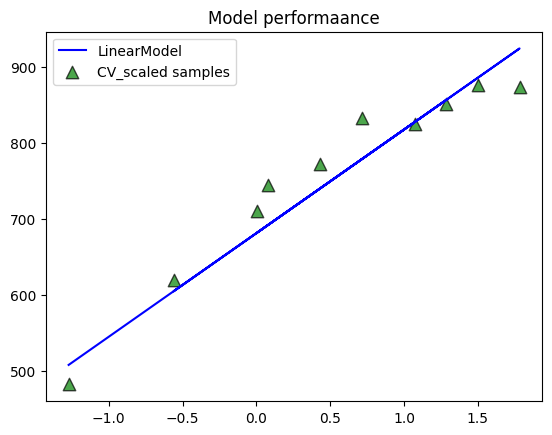

In [20]:
plt.plot(X_cv_scaled,y_cv_hat,c = "blue",label='LinearModel')

# scatter plot
plt.scatter(X_cv_scaled,y_cv,color='green',marker='^',s=80,alpha=0.7,edgecolors='k',label='CV_scaled samples')
plt.legend()
plt.title("Model performaance")
plt.show()


# Test Set

In [21]:
X_test_scaled = scaler.transform(X_test)
y_hat_test = linear_model.predict(X_test_scaled)

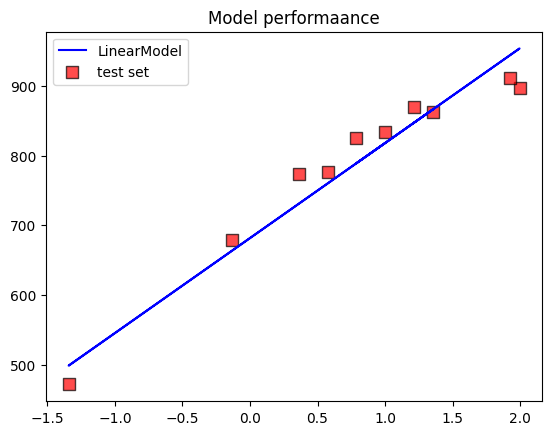

In [22]:
plt.plot(X_test_scaled,y_hat_test,c = "blue",label='LinearModel')

# scatter plot
plt.scatter(X_test_scaled,y_test,color='red',marker='s',s=80,alpha=0.7,edgecolors='k',label='test set')
plt.legend()
plt.title("Model performaance")
plt.show()


In [23]:
print(f"Mean used to scale the test set: {scaler.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the test set: {scaler.scale_.squeeze():.2f}")
print(f"test MSE: {mean_squared_error(y_test,y_hat_test) / 2}")

Mean used to scale the test set: 2504.06
Standard deviation used to scale the test set: 574.85
test MSE: 467.2625052403795


#### The model’s performance wasn’t good enough due to the `linear model`, so we will try a `non-linear model` using `ploynomial features` instead

---
# $Polynomial features$

#### From the graph we saw that the target `y` rises more at smaller values of `x`, a straight line `might not fit perfectly` beacuse of the `y` seems to flatten out as `x` increases. 

we will add `polynomial features` to see if we can get a better performance

In [24]:
from sklearn.preprocessing import PolynomialFeatures

The `PolynomialFeatures` returns the first degree of the feature in `col 1` and the second degree in `col 2`

In [25]:
polynomial_f = PolynomialFeatures(degree=2,include_bias=False)#polynomial feature
poly_scaler = StandardScaler()# polynomail scaler

X_train_poly = polynomial_f.fit_transform(X_train)
X_train_poly.shape

(30, 2)

In [26]:
print(f'ply feature before scaling \n{X_train_poly[:5]}')

ply feature before scaling 
[[3.32446939e+03 1.10520967e+07]
 [2.34487755e+03 5.49845073e+06]
 [3.48773469e+03 1.21642933e+07]
 [2.63059184e+03 6.92001341e+06]
 [2.58977551e+03 6.70693719e+06]]


In [27]:
# applying the scaler on the polynomial features
X_train_poly_scaled = poly_scaler.fit_transform(X_train_poly)

In [28]:
print(f'ply feature after scaling : \n{X_train_poly_scaled[:5]}')

ply feature after scaling : 
[[ 1.42715997  1.47236856]
 [-0.27691164 -0.36461881]
 [ 1.71117191  1.84025141]
 [ 0.22010925  0.1055935 ]
 [ 0.14910627  0.03511397]]


# fit the polynomial training set

In [29]:
# model
poly_model = LinearRegression()
poly_model.fit(X_train_poly_scaled,y_train)

LinearRegression()

In [30]:
y_poly_hat = poly_model.predict(X_train_poly_scaled)

In [31]:
print(f"the Mean used to scale Training set : {poly_scaler.mean_.squeeze()}")
print(f"the STD used to scale Training set : {poly_scaler.scale_.squeeze()}")
print(f"the MSE of  training set : {mean_squared_error(y_train,y_poly_hat)}")

the Mean used to scale Training set : [2.50406122e+03 6.60077937e+06]
the STD used to scale Training set : [5.74853681e+02 3.02323580e+06]
the MSE of  training set : 98.22321866805031


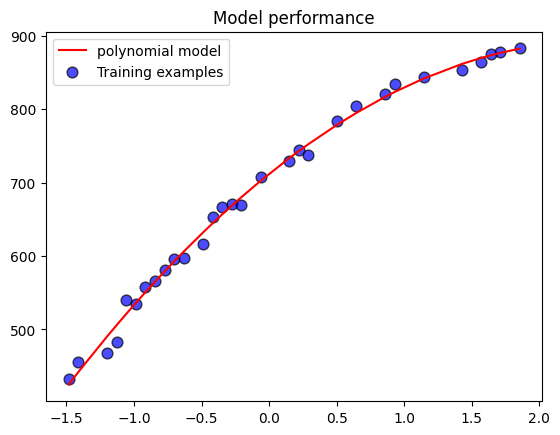

In [32]:
# sort the values 
sort_idx = np.argsort(X_train_poly_scaled[:, 0])  # sort by first column
X_sorted = X_train_poly_scaled[sort_idx]
y_sorted = y_poly_hat[sort_idx]

# plot model 
plt.plot(X_sorted[:, 0], y_sorted, c="red", label="polynomial model")

# scatter plot 
plt.scatter(X_train_poly_scaled[:, 0], y_train,
            marker='o', s=60, alpha=0.7,
            facecolors='blue', edgecolors='k',
            label='Training examples')

plt.title("Model performance")
plt.legend()
plt.show()

In [33]:
# fit the CV polynomial set

In [34]:
X_cv_poly = polynomial_f.transform(X_cv)
X_cv_poly_scaled = poly_scaler.transform(X_cv_poly)
y_cv_hat = poly_model.predict(X_cv_poly_scaled)

In [35]:
print(f"Training MSE: {mean_squared_error(y_train, y_poly_hat) / 2}")
print(f"Cross validation MSE: {mean_squared_error(y_cv, y_cv_hat) / 2}")

Training MSE: 49.111609334025154
Cross validation MSE: 87.6984121111191


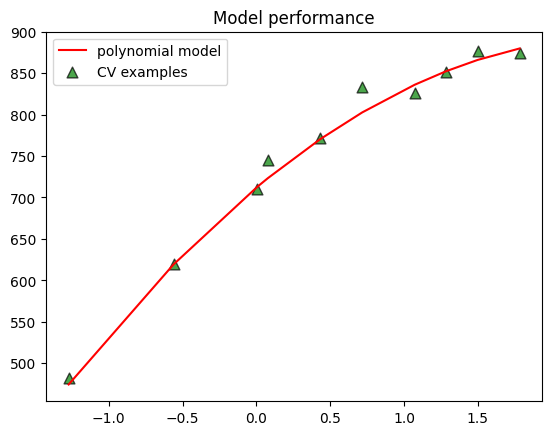

In [36]:
# sort the values 
sort_idx = np.argsort(X_cv_poly_scaled[:, 0])  # sort by first column
X_sorted = X_cv_poly_scaled[sort_idx]
y_sorted = y_cv_hat[sort_idx]

# plot model 
plt.plot(X_sorted[:, 0], y_sorted, c="red", label="polynomial model")

# scatter plot 
plt.scatter(X_cv_poly_scaled[:, 0], y_cv,
            marker='^', s=60, alpha=0.7,
            facecolors='green', edgecolors='k',
            label='CV examples')

plt.title("Model performance")
plt.legend()
plt.show()

---
## the MSEs are significantly better for both the training and cross validation set when we added the 2nd order polynomial

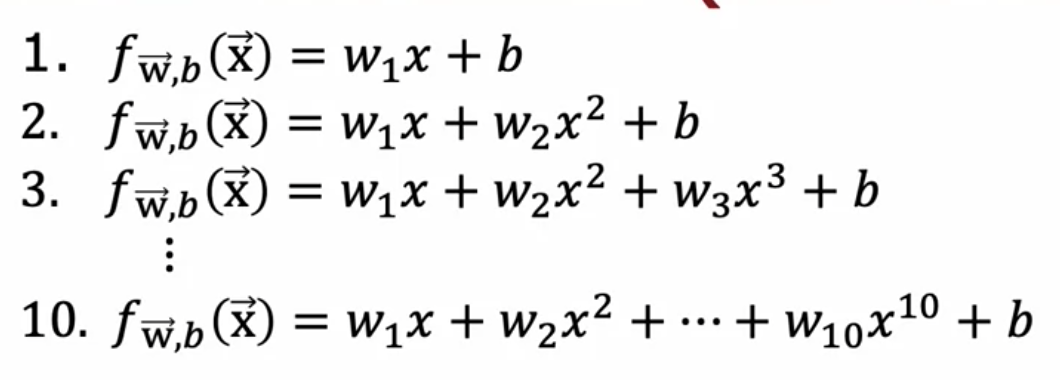


## loop that contains all the steps in the previous code cells

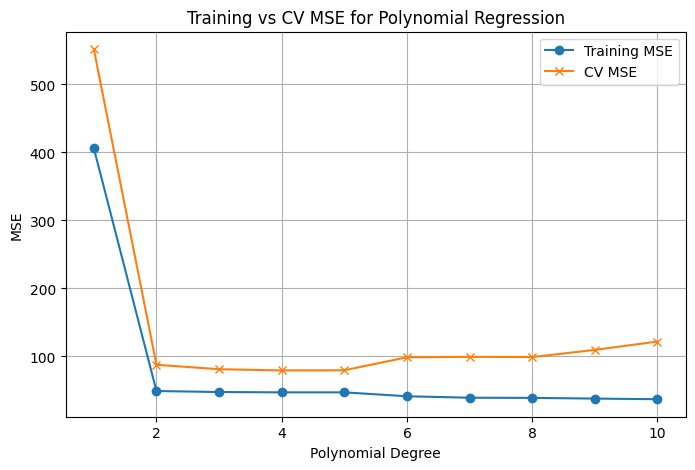

In [37]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

# Loop over 10 times. Each adding one more degree of polynomial higher than the last.
for degree in range(1,11):
    
    # Add polynomial features to the training set
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(X_train)
    polys.append(poly)
    
    # Scale the training set
    scaler_poly = StandardScaler()
    X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)
    scalers.append(scaler_poly)
    
    # Create and train the model
    model = LinearRegression()
    model.fit(X_train_mapped_scaled, y_train )
    models.append(model)
    
    # Compute the training MSE
    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)
    
    # Add polynomial features and scale the cross validation set
    X_cv_mapped = poly.transform(X_cv)
    X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)
    
    # Compute the cross validation MSE
    yhat = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    cv_mses.append(cv_mse)



degrees = list(range(1, 11))

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mses, label="Training MSE", marker='o')
plt.plot(degrees, cv_mses, label="CV MSE", marker='x')
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs CV MSE for Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
import pandas as pd

degrees = list(range(1, 11))

results_df = pd.DataFrame({
    "Degree": degrees,
    "Training MSE": train_mses,
    "CV MSE": cv_mses
})

print(results_df)


   Degree  Training MSE      CV MSE
0       1    406.193742  551.778903
1       2     49.111609   87.698412
2       3     47.616322   81.150879
3       4     47.146466   79.431349
4       5     47.142575   79.586859
5       6     41.383878   98.742262
6       7     39.249611   99.323454
7       8     38.981364   99.048456
8       9     37.971708  109.589529
9      10     37.036468  121.850675


### Choosing the best model

When selecting a model, you want to choose one that performs well both on the training and cross validation set. It implies that it is able to learn the patterns from your training set without overfitting. If you used the defaults in this lab, you will notice a sharp drop in cross validation error from the models with degree=1 to degree=2. This is followed by a relatively flat line up to degree=5. After that, however, the cross validation error is generally getting worse as you add more polynomial features. Given these, you can decide to use the model with the lowest `cv_mse` as the one best suited for your application.

In [39]:
# Get the model with the lowest CV MSE (add 1 because list indices start at 0)
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree={degree}")

Lowest CV MSE is found in the model with degree=4


In [40]:
# Add polynomial features to the test set
X_test_mapped = polys[degree-1].transform(X_test)

# Scale the test set
X_test_mapped_scaled = scalers[degree-1].transform(X_test_mapped)

# Compute the test MSE
yhat = models[degree-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Training MSE: {train_mses[degree-1]:.2f}")
print(f"Cross Validation MSE: {cv_mses[degree-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 47.15
Cross Validation MSE: 79.43
Test MSE: 104.63
